In [1]:
import sys
import os

parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.datasets import fetch_california_housing, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression as SklearnLR

from src.linear_regression import LinearRegression as CustomLR
from src.linear_regression_gd import LinearRegressionGD
from src.weighted_least_squares import WeightedLeastSquares

In [2]:
# ============================================================
# CELL 3 — Load California Housing dataset
# ============================================================

california = fetch_california_housing(as_frame=True)

X = california['data'][['MedInc']]
y = california['target']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature (X) preview:")
print(X.head())
print("\nTarget (y) preview:")
print(y.head())


X shape: (20640, 1)
y shape: (20640,)

Feature (X) preview:
   MedInc
0  8.3252
1  8.3014
2  7.2574
3  5.6431
4  3.8462

Target (y) preview:
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64


In [3]:
# ============================================================
# CELL 4 — Train / validation split  (Part 4.1.3)
# ============================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    train_size=100,
    test_size=100,
    random_state=42
)

x_train_arr = X_train["MedInc"].values
x_val_arr   = X_val["MedInc"].values
y_train_arr = y_train.values
y_val_arr   = y_val.values

In [4]:
# ============================================================
# CELL 5 — Part 4.1.1: OLS sanity check
# ============================================================
print("--- Running Sanity Check for OLS ---")

np.random.seed(42)
X_random = np.random.rand(100, 5)
y_random = (3 * X_random[:, 0]
            + 1.5 * X_random[:, 2]
            - 2 * X_random[:, 4]
            + np.random.randn(100) * 0.1)

sk_model = SklearnLR(fit_intercept=True)
sk_model.fit(X_random, y_random)
sk_preds = sk_model.predict(X_random)

my_model = CustomLR()
my_model.fit(X_random, y_random)
my_preds = my_model.predict(X_random)

is_match = np.allclose(sk_preds, my_preds, atol=1e-9)
print(f"Outputs match within 10^-9: {is_match}")
if is_match:
    print("Sanity check passed! Custom OLS is mathematically identical to sklearn.")
else:
    print("Sanity check failed. Check your matrix inversion math in src!")

--- Running Sanity Check for OLS ---
Outputs match within 10^-9: True
Sanity check passed! Custom OLS is mathematically identical to sklearn.


OLS  val MSE: 14.1721   RMSE: 3.7646
WLS(uniform) == OLS check: max weight diff = 1.78e-15  ✓
WLS  val MSE: 13.8911   RMSE: 3.7271
Improvement: 1.98%


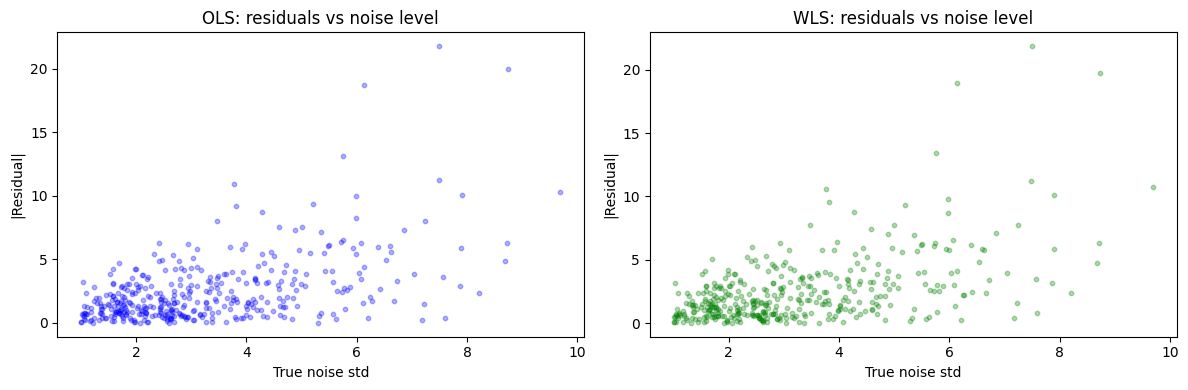

In [5]:
# ============================================================
# BONUS 1 — Weighted Least Squares
# ============================================================
from src.weighted_least_squares import WeightedLeastSquares
from src.linear_regression import LinearRegression as OLS
import numpy as np
import matplotlib.pyplot as plt

# ── Demo: heteroscedastic data (noise grows with X[:,0]) ──
# This is the classical use-case where WLS is provably optimal (Gauss-Markov).
np.random.seed(42)
n = 500
X_demo = np.random.randn(n, 3)
noise_std = 1.0 + 3.0 * np.abs(X_demo[:, 0])   # noise proportional to |X_0|
y_demo = (2 * X_demo[:, 0]
          - 1.5 * X_demo[:, 1]
          + 0.5 * X_demo[:, 2]
          + np.random.randn(n) * noise_std)

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_tr, X_va, y_tr, y_va = train_test_split(X_demo, y_demo, test_size=0.2, random_state=42)

# 1. OLS baseline
ols = OLS()
ols.fit(X_tr, y_tr)
ols_mse = mean_squared_error(y_va, ols.predict(X_va))
print(f"OLS  val MSE: {ols_mse:.4f}   RMSE: {np.sqrt(ols_mse):.4f}")

# 2. Sanity check: WLS with uniform weights must equal OLS
wls_uniform = WeightedLeastSquares()
wls_uniform.fit(X_tr, y_tr)          # no sample_weights → defaults to uniform
diff = np.max(np.abs(wls_uniform.weights - ols.weights))
print(f"WLS(uniform) == OLS check: max weight diff = {diff:.2e}  ✓")

# 3. WLS with theoretically correct weights = 1 / noise_variance
noise_proxy = 1.0 + 3.0 * np.abs(X_tr[:, 0])   # known heteroscedastic structure
sample_weights = 1.0 / (noise_proxy ** 2)
sample_weights = sample_weights / sample_weights.mean()  # normalise to mean=1

wls = WeightedLeastSquares()
wls.fit(X_tr, y_tr, sample_weights=sample_weights)
wls_mse = mean_squared_error(y_va, wls.predict(X_va))
print(f"WLS  val MSE: {wls_mse:.4f}   RMSE: {np.sqrt(wls_mse):.4f}")
pct = 100 * (ols_mse - wls_mse) / ols_mse
print(f"Improvement: {pct:.2f}%")

# 4. Visualise: residuals vs noise level
ols_res = np.abs(y_tr - ols.predict(X_tr))
wls_res = np.abs(y_tr - wls.predict(X_tr))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(noise_proxy, ols_res, alpha=0.3, s=10, color='blue')
axes[0].set_xlabel('True noise std'); axes[0].set_ylabel('|Residual|')
axes[0].set_title('OLS: residuals vs noise level')
axes[1].scatter(noise_proxy, wls_res, alpha=0.3, s=10, color='green')
axes[1].set_xlabel('True noise std'); axes[1].set_ylabel('|Residual|')
axes[1].set_title('WLS: residuals vs noise level')
plt.tight_layout()
plt.savefig('../figures/Bonus1_WLS_Residuals.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

Learning Rate 0.001 converged in 1000 iterations with a final MSE of 391.9509.
Learning Rate 0.01 converged in 823 iterations with a final MSE of 0.2322.
Learning Rate 0.1 converged in 90 iterations with a final MSE of 0.2322.


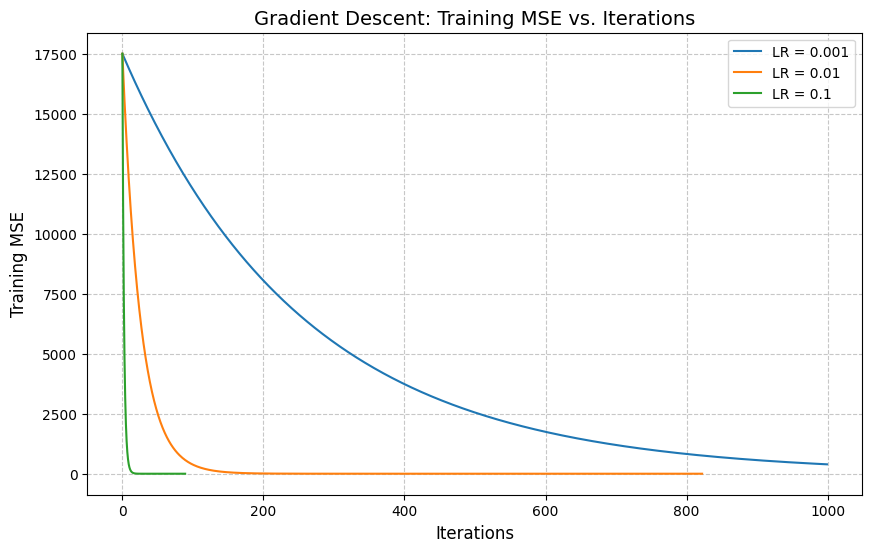

In [6]:
# ============================================================
# CELL 6 — Part 4.1.2: Gradient descent experiments
# ============================================================
X_syn, y_syn = make_regression(n_samples=1000, n_features=10, noise=0.5, random_state=42)

learning_rates = [0.001, 0.01, 0.1]
gd_models = {}

plt.figure(figsize=(10, 6))

for current_lr in learning_rates:
    model_gd = LinearRegressionGD(lr=current_lr)
    model_gd.fit(X_syn, y_syn)
    gd_models[current_lr] = model_gd
    plt.plot(model_gd.loss_history, label=f'LR = {current_lr}')
    
    # Extract the last error from the history
    final_error = model_gd.loss_history[-1]
    
    # Updated print statement formatting the final error to 4 decimal places
    print(f"Learning Rate {current_lr} converged in {len(model_gd.loss_history)} iterations with a final MSE of {final_error:.4f}.")

plt.xlabel('Iterations', fontsize=12)
plt.ylabel('Training MSE', fontsize=12)
plt.title('Gradient Descent: Training MSE vs. Iterations', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('../figures/Gradient_Descent_Training_MSE_Iterations.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# ============================================================
# CELL 7 — Part 4.1.2: Compare GD weights with OLS weights
# ============================================================
print("\n--- Weight Comparison (GD vs OLS) ---")

ols_model = CustomLR()
ols_model.fit(X_syn, y_syn)

best_gd_model = gd_models[0.1]
weights_match = np.allclose(best_gd_model.w_weights, ols_model.weights, atol=1e-4)

print(f"Do the GD weights (LR=0.1) match OLS weights within 10^-4? {weights_match}")
if weights_match:
    print("Success! Gradient Descent converged to the exact same global minimum as OLS.")
else:
    print("Failed: Weights did not match perfectly. Double check your gradient math!")


--- Weight Comparison (GD vs OLS) ---
Do the GD weights (LR=0.1) match OLS weights within 10^-4? True
Success! Gradient Descent converged to the exact same global minimum as OLS.


In [8]:
# ============================================================
# CELL 8 — Part 4.1.3: Polynomial fitting & overfitting
# ============================================================
train_mse_list = []
val_mse_list   = []
degrees = range(1, 13)

for d in degrees:
    X_train_poly = np.column_stack([x_train_arr**i for i in range(1, d + 1)])
    X_val_poly   = np.column_stack([x_val_arr**i   for i in range(1, d + 1)])

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_poly)
    X_val_scaled   = scaler.transform(X_val_poly)

    model = CustomLR()
    model.fit(X_train_scaled, y_train_arr)

    y_train_pred = model.predict(X_train_scaled)
    y_val_pred   = model.predict(X_val_scaled)

    train_mse_list.append(mean_squared_error(y_train_arr, y_train_pred))
    val_mse_list.append(mean_squared_error(y_val_arr,   y_val_pred))

print("Experiment loop complete! MSE values successfully stored.")
print(train_mse_list)
print(val_mse_list)

Experiment loop complete! MSE values successfully stored.
[0.6425542440376449, 0.6125081664317754, 0.6121250577105978, 0.5993466756469221, 0.5967329316683178, 0.5863296326782069, 0.5757119029711455, 0.5514246816048096, 0.550803058052713, 0.5508270855498862, 0.5647657208146523, 0.5494528522528216]
[0.76629584692194, 0.7624425654751512, 0.7663375653691108, 0.7572854560146318, 0.7629947414996409, 0.7768353127789591, 0.7543216507684021, 0.745659663509728, 0.7500442782783024, 0.7502926920582169, 0.7511638408416182, 0.7495711396406008]


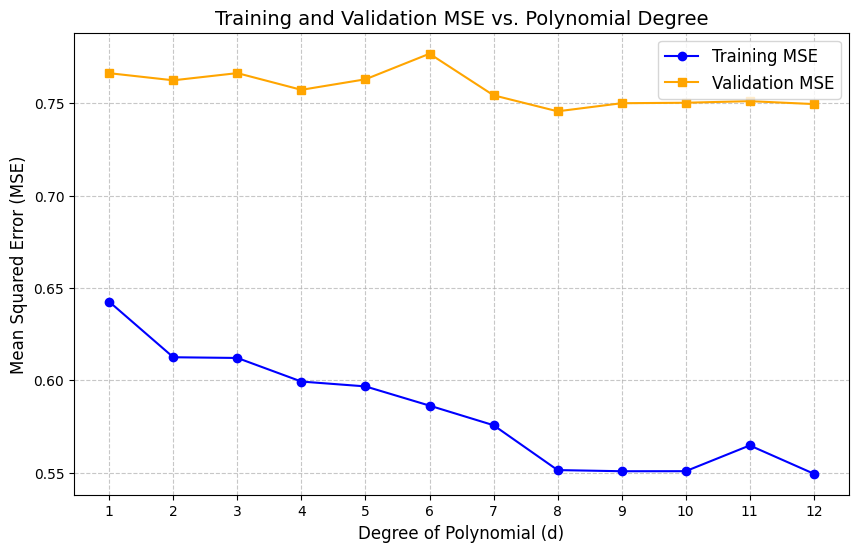

--- Results ---
The degree with the lowest validation MSE is: d = 8
The lowest validation MSE achieved is: 0.7457


In [9]:
# ============================================================
# CELL 9 — Part 4.1.3: Plot Training vs Validation MSE
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mse_list, label='Training MSE',   marker='o', color='blue')
plt.plot(degrees, val_mse_list,   label='Validation MSE', marker='s', color='orange')
plt.xlabel('Degree of Polynomial (d)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.title('Training and Validation MSE vs. Polynomial Degree', fontsize=14)
plt.xticks(degrees)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('../figures/Training and Validation MSE vs. Polynomial Degree.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

best_index    = np.argmin(val_mse_list)
best_d        = list(degrees)[best_index]
lowest_val_mse = val_mse_list[best_index]
print(f"--- Results ---")
print(f"The degree with the lowest validation MSE is: d = {best_d}")
print(f"The lowest validation MSE achieved is: {lowest_val_mse:.4f}")

In [10]:
# ============================================================
# CELL 10 — Part 4.1.5: Prediction intervals (d=5 and d=12)
# ============================================================
import scipy.stats as stats

# ------------------------------------------------------------
# 1. Calculate for d = 5
# ------------------------------------------------------------
d_5 = 5

X_train_poly_5 = np.column_stack([x_train_arr**i for i in range(1, d_5 + 1)])
X_val_poly_5   = np.column_stack([x_val_arr**i   for i in range(1, d_5 + 1)])

scaler_5 = StandardScaler()
X_train_scaled_5 = scaler_5.fit_transform(X_train_poly_5)
X_val_scaled_5   = scaler_5.transform(X_val_poly_5)

model_d5 = CustomLR()
model_d5.fit(X_train_scaled_5, y_train_arr)

X_train_design_5 = np.column_stack([np.ones(len(X_train_scaled_5)), X_train_scaled_5])
X_val_design_5   = np.column_stack([np.ones(len(X_val_scaled_5)),   X_val_scaled_5])

N_5 = X_train_design_5.shape[0]
p_5 = X_train_design_5.shape[1]

y_train_pred_5  = model_d5.predict(X_train_scaled_5)
sigma_squared_5 = (1 / (N_5 - p_5)) * np.sum((y_train_arr - y_train_pred_5)**2)

XTX_inv_5 = np.linalg.inv(X_train_design_5.T @ X_train_design_5)
t_val_5   = stats.t.ppf(0.975, df=N_5 - p_5)

lower_bounds_5 = []
upper_bounds_5 = []
y_val_pred_5   = model_d5.predict(X_val_scaled_5)

for i in range(len(X_val_design_5)):
    x_star          = X_val_design_5[i]
    leverage        = x_star.T @ XTX_inv_5 @ x_star
    margin_of_error = t_val_5 * np.sqrt(sigma_squared_5 * (1 + leverage))
    prediction      = y_val_pred_5[i]
    lower_bounds_5.append(prediction - margin_of_error)
    upper_bounds_5.append(prediction + margin_of_error)

print("d=5 prediction bounds calculated successfully!")


# ------------------------------------------------------------
# 2. Calculate for d = 12
# ------------------------------------------------------------
d_12 = 12

X_train_poly_12 = np.column_stack([x_train_arr**i for i in range(1, d_12 + 1)])
X_val_poly_12   = np.column_stack([x_val_arr**i   for i in range(1, d_12 + 1)])

scaler_12 = StandardScaler()
X_train_scaled_12 = scaler_12.fit_transform(X_train_poly_12)
X_val_scaled_12   = scaler_12.transform(X_val_poly_12)

model_d12 = CustomLR()
model_d12.fit(X_train_scaled_12, y_train_arr)

X_train_design_12 = np.column_stack([np.ones(len(X_train_scaled_12)), X_train_scaled_12])
X_val_design_12   = np.column_stack([np.ones(len(X_val_scaled_12)),   X_val_scaled_12])

N_12 = X_train_design_12.shape[0]
p_12 = X_train_design_12.shape[1]

y_train_pred_12  = model_d12.predict(X_train_scaled_12)
sigma_squared_12 = (1 / (N_12 - p_12)) * np.sum((y_train_arr - y_train_pred_12)**2)

XTX_inv_12 = np.linalg.inv(X_train_design_12.T @ X_train_design_12)
t_val_12   = stats.t.ppf(0.975, df=N_12 - p_12)

lower_bounds_12 = []
upper_bounds_12 = []
y_val_pred_12   = model_d12.predict(X_val_scaled_12)

for i in range(len(X_val_design_12)):
    x_star          = X_val_design_12[i]
    leverage        = x_star.T @ XTX_inv_12 @ x_star
    margin_of_error = t_val_12 * np.sqrt(sigma_squared_12 * (1 + leverage))
    prediction      = y_val_pred_12[i]
    lower_bounds_12.append(prediction - margin_of_error)
    upper_bounds_12.append(prediction + margin_of_error)

print("d=12 prediction bounds calculated successfully!")

d=5 prediction bounds calculated successfully!
d=12 prediction bounds calculated successfully!


Mean interval width, d = 5:  3.2176
Mean interval width, d = 12: 3.2610


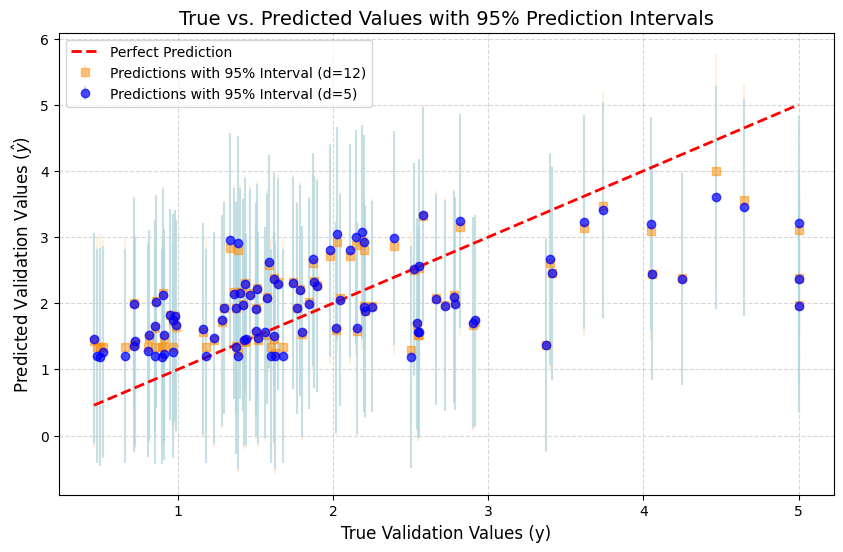

In [11]:
# ============================================================
# CELL 11 — Part 4.1.5: Plot prediction intervals (d=5 and d=12)
# ============================================================

# 1. Calculate error bars (distance from prediction to upper bound)
error_bars_5  = np.array(upper_bounds_5) - np.array(y_val_pred_5)
error_bars_12 = np.array(upper_bounds_12) - np.array(y_val_pred_12)

# 2. Calculate and print Mean Interval Widths (Full width is 2 * error bar)
mean_width_5  = np.mean(2 * error_bars_5)
mean_width_12 = np.mean(2 * error_bars_12)

print(f"Mean interval width, d = 5:  {mean_width_5:.4f}")
print(f"Mean interval width, d = 12: {mean_width_12:.4f}")

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot d=12 first so it sits behind d=5 (since it will likely have wider, messier bars)
plt.errorbar(
    y_val_arr, y_val_pred_12,
    yerr=error_bars_12,
    fmt='s',                      # Squares for d=12
    color='darkorange',
    ecolor='moccasin',
    alpha=0.5,
    label='Predictions with 95% Interval (d=12)'
)

# Plot d=5 overlaying it
plt.errorbar(
    y_val_arr, y_val_pred_5,
    yerr=error_bars_5,
    fmt='o',                     
    color='blue',
    ecolor='lightblue',
    alpha=0.7,
    label='Predictions with 95% Interval (d=5)'
)

# Perfect prediction line
min_val = np.min(y_val_arr)
max_val = np.max(y_val_arr)
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.xlabel('True Validation Values (y)', fontsize=12)
plt.ylabel(r'Predicted Validation Values ($\hat{y}$)', fontsize=12)
plt.title('True vs. Predicted Values with 95% Prediction Intervals', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# Save and show
plt.savefig('../figures/Prediction_Intervals_Comparison_d5_d12.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()